<a href="https://colab.research.google.com/github/jeet-jana/Studentt-Pass-Fail-Prediction-Model/blob/main/student_pass.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

from google.colab import files
uploaded = files.upload()
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

# kagglehub.dataset_download('<owner>/<dataset-slug>')

Saving student_performance.csv to student_performance (1).csv


In [ ]:
data = pd.read_csv("student_performance.csv")
data.head()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            500 non-null    object 
 1   gender                500 non-null    object 
 2   age                   500 non-null    int64  
 3   study_hours_per_week  500 non-null    int64  
 4   attendance_rate       500 non-null    float64
 5   parent_education      383 non-null    object 
 6   internet_access       500 non-null    object 
 7   extracurricular       500 non-null    object 
 8   previous_score        500 non-null    int64  
 9   final_score           500 non-null    int64  
 10  passed                500 non-null    object 
dtypes: float64(1), int64(4), object(6)
memory usage: 43.1+ KB


In [ ]:
data.head()

,student_id,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,passed
0,STU0001,Male,15,25,63.8,Bachelor,Yes,Yes,41,67,Yes
1,STU0002,Female,15,2,54.7,Bachelor,Yes,Yes,83,28,No
2,STU0003,Female,19,10,90.5,High School,Yes,No,73,49,No
3,STU0004,Male,16,26,66.8,High School,No,Yes,75,70,Yes
4,STU0005,Female,15,25,73.0,High School,No,Yes,67,77,Yes


<Axes: >

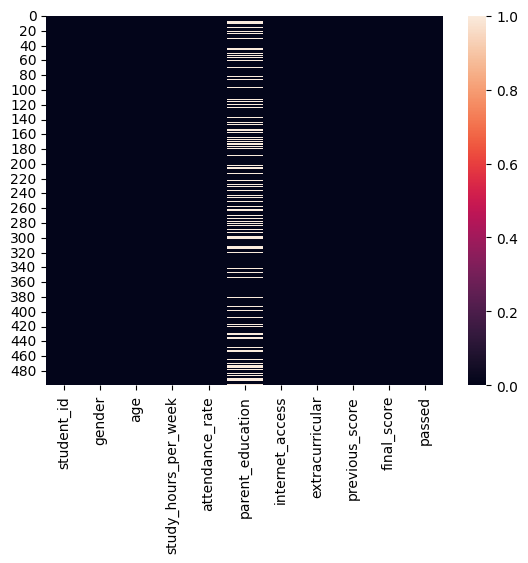

In [ ]:
sns.heatmap(data.isnull())

In [ ]:
data['passed']=[1 if i == "Yes" else 0 for i in data.passed]
data['gender']=[1 if i == "Male" else 0 for i in data.gender]
data['parent_education']=[1 if i == "Bachelor" else 0 for i in data.parent_education]
data['internet_access']=[1 if i == "Yes" else 0 for i in data.internet_access]
data['extracurricular']=[1 if i == "Yes" else 0 for i in data.extracurricular]
data = data.drop(['student_id','final_score'],axis = 1)
data.head()


,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,passed
0,1,15,25,63.8,1,1,1,41,1
1,0,15,2,54.7,1,1,1,83,0
2,0,19,10,90.5,0,1,0,73,0
3,1,16,26,66.8,0,0,1,75,1
4,0,15,25,73.0,0,0,1,67,1


In [ ]:
y = data['passed']
x = data.drop(['passed'],axis = 1)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
stand = StandardScaler()
x_stand = stand.fit_transform(x)

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x_stand,y,test_size= 30,random_state=64)

In [ ]:
lr = LogisticRegression()
lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)

In [ ]:
accuracy = accuracy_score(y_pred,y_test)
print(f"Accuracy is {accuracy}")

Accuracy is 0.8


In [ ]:
import joblib
joblib.dump(lr, "Pass_model.pkl")
joblib.dump(stand,"Standard__Normal_data.pkl")

['Standard__Normal_data.pkl']